3. Seq2Seq 모델과 어텐션

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input
from tensorflow.keras.utils import to_categorical

In [2]:
X_data = [[1,2,3], [1,4,5], [6,7,8]]
Y_data = [[10,20,30], [10,20,50], [60,30]]

X_train = pad_sequences(X_data, maxlen = 5)
Y_train = pad_sequences(Y_data, maxlen = 4)

input_vocab_size = np.max(X_train) + 1
output_vocab_size = np.max(Y_train) + 1

y_train = to_categorical(Y_train, num_classes = output_vocab_size)

encoder_inputs = Input(shape = (5,))
enc_emb = Embedding(input_dim = input_vocab_size, output_dim = 64)(encoder_inputs)
encoder_lstm = LSTM(128, return_state = True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

decoder_inputs = Input(shape = (4,))
dec_emb = Embedding(input_dim = output_vocab_size, output_dim = 64)(decoder_inputs)
decoder_lstm = LSTM(128, return_sequences = True, return_state = True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state = [state_h, state_c])
decoder_dense = Dense(output_vocab_size, activation = 'softmax')
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

history = model.fit([X_train, Y_train], y_train, batch_size = 2, epochs = 25, validation_split = 0.2)

y_vloss = history.history['val_loss']
y_loss = history.history['loss']
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker = '.', c = 'red', label = 'Testset_loss')
plt.plot(x_len, y_vloss, marker = '.', c = 'blue', label = 'Trainset_loss')
plt.legend(loc = 'upperdight')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

ValueError: Received an invalid value for `units`, expected a positive integer. Received: units=61

Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 4.1090 - val_accuracy: 0.5000 - val_loss: 4.0969
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 4.0937 - val_accuracy: 0.5000 - val_loss: 4.0874
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5000 - loss: 4.0777 - val_accuracy: 0.5000 - val_loss: 4.0771
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 4.0600 - val_accuracy: 0.5000 - val_loss: 4.0655
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5000 - loss: 4.0398 - val_accuracy: 0.5000 - val_loss: 4.0523
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5000 - loss: 4.0163 - val_accuracy: 0.5000 - val_loss: 4.0369
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5000 - loss: 3.9881 - val_accuracy: 0.5000 - val_loss: 4.0186
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5000 - loss: 3.9541 - val_accuracy: 0.5000 - val_loss: 3.996

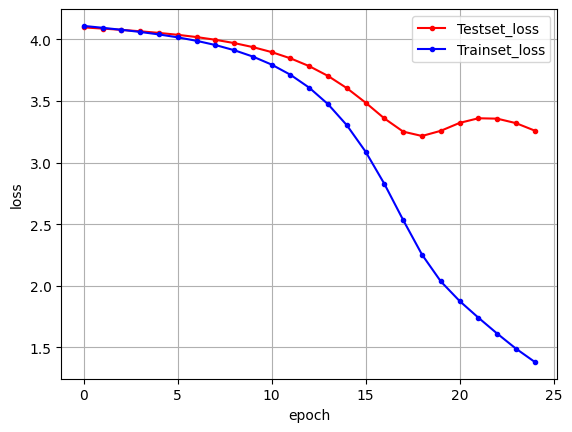

In [4]:
# 데이터 설정
X_data = [[1,2,3], [1,4,5], [6,7,8]]
Y_data = [[10,20,30], [10,20,50], [60,30]]

# 패딩
X_train = pad_sequences(X_data, maxlen = 5)
Y_train = pad_sequences(Y_data, maxlen = 4)

# [해결책] numpy.int64 타입을 순수 파이썬 int 타입으로 변환합니다.
input_vocab_size = int(np.max(X_train) + 1)
output_vocab_size = int(np.max(Y_train) + 1)

# 원-핫 인코딩
y_train = to_categorical(Y_train, num_classes = output_vocab_size)

# 인코더 설계
encoder_inputs = Input(shape = (5,))
enc_emb = Embedding(input_dim = input_vocab_size, output_dim = 64)(encoder_inputs)
encoder_lstm = LSTM(128, return_state = True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

# 디코더 설계
decoder_inputs = Input(shape = (4,))
dec_emb = Embedding(input_dim = output_vocab_size, output_dim = 64)(decoder_inputs)
decoder_lstm = LSTM(128, return_sequences = True, return_state = True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state = [state_h, state_c])

# [오류 지점 해결] output_vocab_size가 파이썬 int이므로 이제 정상 작동합니다.
decoder_dense = Dense(output_vocab_size, activation = 'softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# 모델 구성 및 컴파일
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

# 학습
history = model.fit([X_train, Y_train], y_train, batch_size = 2, epochs = 25, validation_split = 0.2)

# 시각화
y_vloss = history.history['val_loss']
y_loss = history.history['loss']
x_len = np.arange(len(y_loss))

plt.plot(x_len, y_vloss, marker = '.', c = 'red', label = 'Testset_loss')
plt.plot(x_len, y_loss, marker = '.', c = 'blue', label = 'Trainset_loss') # y_loss로 수정
plt.legend(loc = 'upper right') # 오타 수정: upperdight -> upper right
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid()
plt.show()

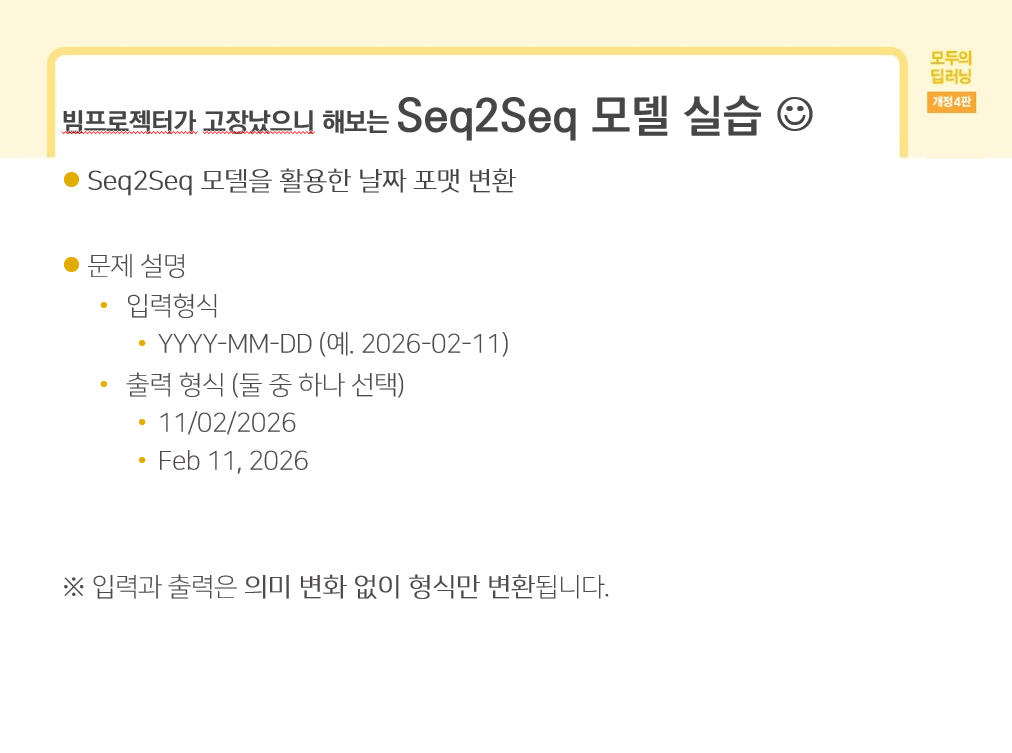

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.models import Model
from datetime import datetime, timedelta

In [15]:
# 1) 데이터 및 사전 생성
# 날짜 표현에 필요한 모든 문자 포함
chars = list("0123456789- ,abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ")
PAD, SOS, EOS = "_", "^", "$"
vocab = [PAD, SOS, EOS] + chars
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for i, c in char2idx.items()}

# 날짜 데이터 생성 함수 (2026-02-11 -> Feb 11, 2026)
def make_date_samples(n=10000):
    X, Y = [], []
    start_date = datetime(1900, 1, 1)
    for _ in range(n):
        random_days = np.random.randint(0, 50000) # 약 130년치 데이터
        dt = start_date + timedelta(days=random_days)
        
        # 입력 형식: 2026-02-11
        src = dt.strftime("%Y-%m-%d")
        # 출력 형식: Feb 11, 2026
        tgt = dt.strftime("%b %d, %Y")
        
        X.append(src)
        Y.append(tgt)
    return X, Y

X_text, Y_text = make_date_samples(n=10000)
max_in = max(len(s) for s in X_text) + 2
max_out = max(len(s) for s in Y_text) + 2

# 벡터화 함수 (기존 코드와 동일)
def vectorize(src_list, tgt_list):
    encoder_in = np.zeros((len(src_list), max_in, len(vocab)), dtype="float32")
    decoder_in = np.zeros((len(src_list), max_out, len(vocab)), dtype="float32")
    decoder_out = np.zeros((len(src_list), max_out, len(vocab)), dtype="float32")

    for i, (src, tgt) in enumerate(zip(src_list, tgt_list)):
        src_seq = SOS + src + EOS
        tgt_seq = SOS + tgt + EOS

        for t, ch in enumerate(src_seq.ljust(max_in, PAD)):
            encoder_in[i, t, char2idx[ch]] = 1.0

        tgt_seq_pad = tgt_seq.ljust(max_out, PAD)
        for t, ch in enumerate(tgt_seq_pad):
            decoder_in[i, t, char2idx[ch]] = 1.0
            if t > 0:
                decoder_out[i, t-1, char2idx[ch]] = 1.0
    return encoder_in, decoder_in, decoder_out

enc_in, dec_in, dec_out = vectorize(X_text, Y_text)

# 2) 모델 정의 (Encoder-Decoder)
latent_dim = 128
encoder_inputs = Input(shape=(None, len(vocab)))
encoder_lstm = LSTM(latent_dim, return_state=True)
_, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

decoder_inputs = Input(shape=(None, len(vocab)))
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = Dense(len(vocab), activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# 3) 학습
model.fit([enc_in, dec_in], dec_out, batch_size=64, epochs=20, validation_split=0.2)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.3656 - loss: 2.1353 - val_accuracy: 0.5052 - val_loss: 1.4249
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5421 - loss: 1.1769 - val_accuracy: 0.5846 - val_loss: 1.0016
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6023 - loss: 0.9142 - val_accuracy: 0.6133 - val_loss: 0.8481
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6385 - loss: 0.7860 - val_accuracy: 0.6600 - val_loss: 0.7270
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6797 - loss: 0.6816 - val_accuracy: 0.7046 - val_loss: 0.6406
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7123 - loss: 0.6003 - val_accuracy: 0.7400 - val_loss: 0.5578
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7486 - loss: 0.5155 - val_accuracy: 0.7645 - val_loss: 0.4751
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7837 - loss: 0.4320 - val_accu

In [16]:
# 4) 추론 모델 및 decode 함수 (생략 없이 기존 구조 유지)
encoder_model = Model(encoder_inputs, encoder_states)
dec_state_input_h = Input(shape=(latent_dim,))
dec_state_input_c = Input(shape=(latent_dim,))
dec_states_inputs = [dec_state_input_h, dec_state_input_c]
dec_outputs, state_h2, state_c2 = decoder_lstm(decoder_inputs, initial_state=dec_states_inputs)
dec_outputs = decoder_dense(dec_outputs)
decoder_model = Model(inputs = [decoder_inputs] + dec_states_inputs, outputs = [dec_outputs, state_h2, state_c2]) # 수정

# 간결한 추론 함수
def decode_sequence(input_seq_onehot):
    states_value = encoder_model.predict(input_seq_onehot, verbose=0)
    target_seq = np.zeros((1, 1, len(vocab)), dtype="float32")
    target_seq[0, 0, char2idx[SOS]] = 1.0
    decoded = []
    
    for _ in range(max_out):
        # decoder_model 출력 구조에 맞춰 수정
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        sampled_idx = np.argmax(output_tokens[0, -1, :])
        sampled_char = idx2char[sampled_idx]

        if sampled_char == EOS: break
        if sampled_char not in [PAD, SOS]: decoded.append(sampled_char)

        target_seq = np.zeros((1, 1, len(vocab)), dtype="float32")
        target_seq[0, 0, sampled_idx] = 1.0
        states_value = [h, c]
    return "".join(decoded)

def to_onehot_src(s):
    for ch in s:
        if ch not in char2idx:
            raise ValueError(f"사전에 없는 문자: {ch}")
    
    src_seq = (SOS + s + EOS).ljust(max_in, PAD)
    x = np.zeros((1, max_in, len(vocab)), dtype="float32")
    for t, ch in enumerate(src_seq):
        x[0, t, char2idx[ch]] = 1.0
    return x

In [17]:
# 5) 사용자 입력 테스트
print("\n--- 날짜 변환 테스트 (예: 2026-02-11) ---")
while True:
    user_input = input("날짜 입력 (YYYY-MM-DD) (종료: exit): ")
    if user_input.lower() == "exit": break
    try:
        x = to_onehot_src(user_input)
        pred = decode_sequence(x)
        print(f"입력: {user_input} -> 모델 출력: {pred}")
    except:
        print("형식이 올바르지 않거나 알 수 없는 문자가 포함되었습니다.")


--- 날짜 변환 테스트 (예: 2026-02-11) ---
형식이 올바르지 않거나 알 수 없는 문자가 포함되었습니다.
형식이 올바르지 않거나 알 수 없는 문자가 포함되었습니다.
형식이 올바르지 않거나 알 수 없는 문자가 포함되었습니다.
형식이 올바르지 않거나 알 수 없는 문자가 포함되었습니다.


> 문제 풀이 결과 잘못됨

1~2. 단어간 유사성 확인 및 관계성 파악

In [23]:
#아래는 한글을 사용할 때 깨지는 문제에 대한 해결
from matplotlib import font_manager, rc
font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family=font_name)

#그래프의 축 등에서 음수를 표시할 때 minus sign이 깨지는 것 해결
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False

In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
word_embeddings = {
    # 그룹 1: 과일 (Fruits)
    "사과":   [0.80, 0.90],
    "배":     [0.75, 0.85],
    "귤":     [0.82, 0.86],
    "수박":   [0.70, 0.92],
    "딸기":   [0.78, 0.95],

    # 그룹 2: 이동수단 (Vehicles) 
    "자동차": [2.00, 1.70],
    "버스":   [2.10, 1.80],
    "지하철": [1.90, 1.85],
    "자전거": [2.05, 1.60],
    "택시":   [2.15, 1.65],

    # 그룹 3: 감정 (Emotions) 
    "행복":   [0.20, -1.10],
    "기쁨":   [0.25, -1.00],
    "슬픔":   [0.10, -1.30],
    "분노":   [0.05, -1.45],
    "불안":   [0.30, -1.35],

    # 그룹 4: 동물 (Animals) 
    "강아지": [2.20, -1.00],
    "고양이": [2.10, -1.15],
    "토끼":   [2.30, -1.10],
    "호랑이": [2.40, -1.30],
    "곰":     [2.25, -1.35],
}

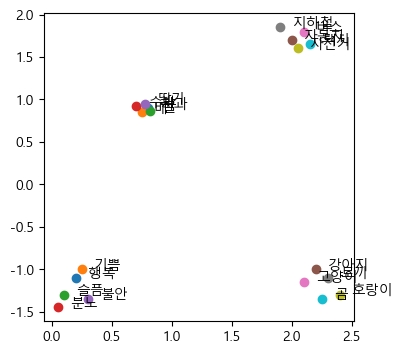

In [24]:
plt.figure(figsize = (4,4))
for word, vec in word_embeddings.items():
    plt.scatter(*vec)
    plt.text(vec[0] + 0.1, vec[1], word)
plt.show()

In [28]:
def dot_prod(vec1, vec2):
    return np.dot(vec1, vec2)

print("귤, 딸기: ", dot_prod(word_embeddings['귤'], word_embeddings['딸기']))
print("귤, 기쁨: ", dot_prod(word_embeddings['귤'], word_embeddings['기쁨']))

귤, 딸기:  1.4566
귤, 기쁨:  -0.655


In [32]:
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

words = list(word_embeddings.keys())
embedding_vectors = np.array(list(word_embeddings.values()))

## 코사인 유사성 확인
similarities = []
for v1 in embedding_vectors:
    row = []
    for v2 in embedding_vectors:
        row.append(cosine_similarity(v1, v2))
    similarities.append(row)

for i in range(len(words)):
    for j in range(len(words)):
        print(f"{words[j] , {words[j]}} 유사성: {similarities[i][j]: .2f}")

('사과', {'사과'}) 유사성:  1.00
('배', {'배'}) 유사성:  1.00
('귤', {'귤'}) 유사성:  1.00
('수박', {'수박'}) 유사성:  1.00
('딸기', {'딸기'}) 유사성:  1.00
('자동차', {'자동차'}) 유사성:  0.99
('버스', {'버스'}) 유사성:  0.99
('지하철', {'지하철'}) 유사성:  1.00
('자전거', {'자전거'}) 유사성:  0.98
('택시', {'택시'}) 유사성:  0.98
('행복', {'행복'}) 유사성: -0.62
('기쁨', {'기쁨'}) 유사성: -0.56
('슬픔', {'슬픔'}) 유사성: -0.69
('분노', {'분노'}) 유사성: -0.72
('불안', {'불안'}) 유사성: -0.59
('강아지', {'강아지'}) 유사성:  0.30
('고양이', {'고양이'}) 유사성:  0.22
('토끼', {'토끼'}) 유사성:  0.28
('호랑이', {'호랑이'}) 유사성:  0.23
('곰', {'곰'}) 유사성:  0.19
('사과', {'사과'}) 유사성:  1.00
('배', {'배'}) 유사성:  1.00
('귤', {'귤'}) 유사성:  1.00
('수박', {'수박'}) 유사성:  1.00
('딸기', {'딸기'}) 유사성:  1.00
('자동차', {'자동차'}) 유사성:  0.99
('버스', {'버스'}) 유사성:  0.99
('지하철', {'지하철'}) 유사성:  1.00
('자전거', {'자전거'}) 유사성:  0.98
('택시', {'택시'}) 유사성:  0.98
('행복', {'행복'}) 유사성: -0.62
('기쁨', {'기쁨'}) 유사성: -0.57
('슬픔', {'슬픔'}) 유사성: -0.70
('분노', {'분노'}) 유사성: -0.73
('불안', {'불안'}) 유사성: -0.59
('강아지', {'강아지'}) 유사성:  0.29
('고양이', {'고양이'}) 유사성:  0.22
('토끼', {'토끼'}) 유사성:  0.27
